In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

In [2]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 30, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [3]:
#data = pd.read_csv("../Data/Day 2/5.36Hz2V.csv", sep = ",")
filename = "../Data/Day 3/20Hz2V.txt"
data = pd.read_table(filename)

match = re.search(r"([\d\.]+)Hz([\d\.]+)V", filename)
if match:
    f = float(match.group(1))
    Vmax = float(match.group(2))   
T = 1/f # s
lamb = 650e-9 # m
background = 1.04 # V, uncertainties irrelevant

In [4]:
# data init
downsampling = 1
i_min, i_max = (1,-1)
if "ms" in data["Time"][0]:
    time = np.array(data["Time"][i_min:i_max:downsampling].astype("float")) / 1000 # s
    print("ms")
else:
    time = np.array(data["Time"][i_min:i_max:downsampling].astype("float"))
channel_a = np.array(data["Channel B"][i_min:i_max:downsampling].replace("∞", Vmax).astype("float")) - background
channel_b = np.array(data["Channel A"][i_min:i_max:downsampling].replace("∞", Vmax).astype("float"))



In [5]:
def pointFinder(y, t, ofs=0):
    # Centrer signalet omkring 0 for nemmere beregning
    y_centered = y - ofs
    
    # Find alle steder hvor signalet skifter fortegn
    sign_changes = np.where(np.diff(np.sign(y_centered)) != 0)[0]
    
    intersects = []
    t1 = []
    
    if len(sign_changes) > 0:
        intersects.append(sign_changes[0])
        t1.append(t[sign_changes[0]])
        
        for idx in sign_changes[1:]:
            if idx - intersects[-1] > 10: 
                intersects.append(idx)
                t1.append(t[idx])

    tops = []
    t2 = []
    for i in range(1, len(intersects)):
        start, end = intersects[i-1], intersects[i]
        interval_y = y[start:end]
        interval_t = t[start:end]
        
        if len(interval_y) == 0: 
            continue

        # Afgør om intervallet er en top eller en dal
        if np.mean(interval_y) > ofs:
            extreme_val = np.max(interval_y)
            # Find alle indekser, der har denne max-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
        else:
            extreme_val = np.min(interval_y)
            # Find alle indekser, der har denne min-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
            
        # Vælg det midterste indeks af plateauet (heltalsdivision giver midten)
        idx = all_indices[len(all_indices) // 2]
            
        tops.append(interval_y[idx])
        t2.append(interval_t[idx])

    intersects = np.array(intersects)
    t1 = np.array(t1)
    tops = np.array(tops)
    t2 = np.array(t2)
    
    dy = 0.1
    maske = (((tops) > (ofs + dy)) | ((tops) < (ofs - dy)))
    
    return intersects, t1, tops[maske], t2[maske]

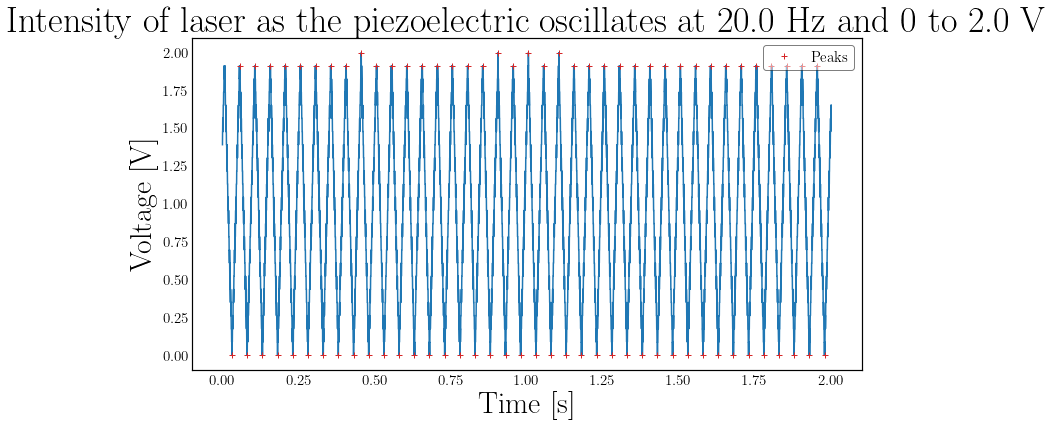

In [6]:
_, _, tops, times = pointFinder(channel_b, time, ofs=np.mean(channel_b))
fig, ax = plt.subplots()

ax.plot(time, channel_b, color="C0")
ax.plot(times, tops, "+", color = "C3", label = "Peaks")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend()

In [7]:
_, _, tops, times = pointFinder(channel_b, time, ofs=np.mean(channel_b))
indices = np.where(np.isin(time, times))[0]
#indices += 100

new_time_parts_up = []
new_channel_b_parts = []
new_channel_a_parts = []
for j in range(int(tops[0] < 1),len(times)-1,2):
    start = indices[j]
    end = indices[j+1]

    interval = time[start:end]
    new_time_parts_up.append(interval - interval[0])
    new_channel_b_parts.append(channel_b[start:end])
    new_channel_a_parts.append(channel_a[start:end])

new_time_up = np.concatenate(new_time_parts_up)
new_channel_b_up = np.concatenate(new_channel_b_parts)
new_channel_a_up = np.concatenate(new_channel_a_parts)

new_time_parts_down = []
new_channel_b_parts = []
new_channel_a_parts = []
for j in range(int(tops[0] > 1),len(times)-1,2):
    start = indices[j]
    end = indices[j+1]

    interval = time[start:end]
    new_time_parts_down.append(interval - interval[0])
    new_channel_b_parts.append(channel_b[start:end])
    new_channel_a_parts.append(channel_a[start:end])

new_time_down = np.concatenate(new_time_parts_down)
new_channel_b_down = np.concatenate(new_channel_b_parts)
new_channel_a_down = np.concatenate(new_channel_a_parts)

In [8]:
a0 = (channel_a.max() - channel_a.min()) / 2
b0 = 1e-7
c0 = 0
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, b0, c0, d0]
lower_bounds = [0,0,0,-5]
upper_bounds = [10,np.inf,np.inf,5]

V_up = lambda t: (2 * Vmax / T * t)
fit_func_up = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V_up(t) + c) + d
fit_up = curve_fit(fit_func_up, new_time_up, new_channel_a_up, p0, maxfev = 10000, ftol=1e-12, xtol=1e-12, gtol=1e-12, bounds = (lower_bounds, upper_bounds))
print(fit_up[0], np.sqrt(np.diag(fit_up[1])))

V_down = lambda t: (-2 * Vmax / T * t + Vmax)
fit_func_down = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V_down(t) + c) + d
fit_down = curve_fit(fit_func_down, new_time_down, new_channel_a_down, p0, ftol=1e-12, xtol=1e-12, gtol=1e-12, maxfev = 10000, bounds = (lower_bounds, upper_bounds))
print(fit_down[0],np.sqrt(np.diag(fit_down[1])))

[2.29331390e+00 1.36000896e-07 5.70181213e-01 4.24409707e+00] [2.29945295e-03 1.74921322e-10 3.18087352e-03 3.53556986e-03]
[2.27197760e+00 1.50738959e-07 1.23547415e+00 4.13690411e+00] [1.10632953e-03 4.10927101e-11 7.91986069e-04 7.35229895e-04]


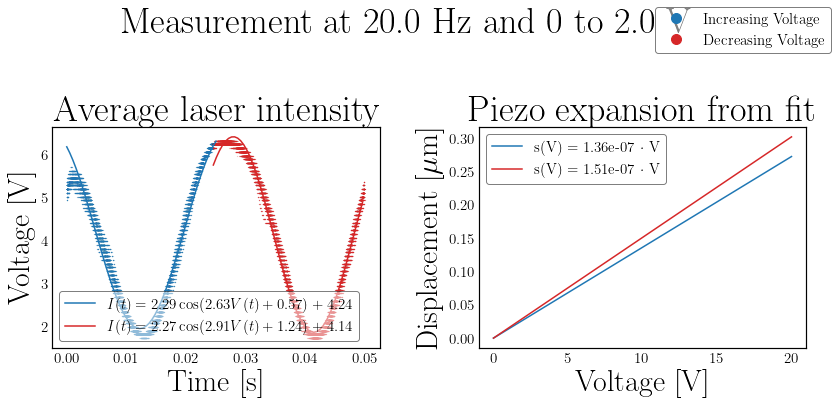

In [9]:
fig, axes = plt.subplots(1,2)

axes[0].plot(new_time_up, new_channel_a_up, "o", markersize = 0.1, color="C0", label ="Increasing Voltage")
axes[0].plot(new_time_down + new_time_up[-1], new_channel_a_down, "o", markersize = 0.1, color="C3", label = "Decreasing Voltage")
fig.legend(markerscale = 100)

t = np.linspace(0, T/2)
a,b,c,d = fit_up[0]
label_up = f"$I(t) = {a:.2f}\\cos({4*np.pi*b/lamb:.2f} V(t) + {c:.2f}) + {d:.2f}$"
plot1, = axes[0].plot(t, fit_func_up(t,*fit_up[0]), color = "C0", label = label_up)
a,b,c,d = fit_down[0]
label_down = f"$I(t) = {a:.2f}\\cos({4*np.pi*b/lamb:.2f} V(t) + {c:.2f}) + {d:.2f}$"
plot2, = axes[0].plot(t + new_time_up[-1], fit_func_down(t,*fit_down[0]), color = "C3", label = label_down)
axes[0].legend(handles = (plot1,plot2), loc = "lower left")

#ax.plot(times, tops, "+", color = "C3", label = "Peaks")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title(f"Average laser intensity")

axes[1].plot(V_up(t) * 10, fit_up[0][1] * V_up(t) * 1e6, color = "C0", label = f"s(V) = {fit_up[0][1]:.2e} $\\cdot$ V")
axes[1].plot(V_down(t) * 10, fit_down[0][1] * V_down(t) * 1e6, color = "C3", label = f"s(V) = {fit_down[0][1]:.2e} $\\cdot$ V")
axes[1].set_xlabel("Voltage [V]")
axes[1].set_ylabel("Displacement [$\\mu$m]")
axes[1].set_title(f"Piezo expansion from fit")
axes[1].legend()

fig.suptitle(f"Measurement at {f} Hz and 0 to {Vmax} V")
fig.tight_layout()

fig.savefig(f"../Figures/IntensityFit({f:.1f}Hz{Vmax:.1f}V).svg")

In [10]:
a0 = (channel_a.max() - channel_a.min()) / 2
b0 = 1e-7
c0 = 0
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, 5e-8, 1e-7, b0, c0, d0]
lower_bounds = [0,0,0,0,0,-5]
upper_bounds = [10,np.inf,np.inf,np.inf,np.inf,5]

V_up = lambda t: (2 * Vmax / T * t)
fit_func_up = lambda t, a, b1,b2,b3, c, d: a*np.cos(2*np.pi / lamb * 2 * (b1 * V_up(t)**3 + b2 * V_up(t)**2 + b3 * V_up(t)) + c) + d
fit_up = curve_fit(fit_func_up, new_time_up, new_channel_a_up, p0, maxfev = 10000, bounds = (lower_bounds, upper_bounds), ftol=1e-12, xtol=1e-12, gtol=1e-12)

V_down = lambda t: (-2 * Vmax / T * t + Vmax)
fit_func_down = lambda t, a, b1,b2,b3, c, d: a*np.cos(2*np.pi / lamb * 2 * (b1 * V_down(t)**3 + b2 * V_down(t)**2 + b3 * V_down(t)) + c) + d
fit_down = curve_fit(fit_func_down, new_time_down, new_channel_a_down, p0, maxfev = 10000, bounds = (lower_bounds, upper_bounds), ftol=1e-12, xtol=1e-12, gtol=1e-12)

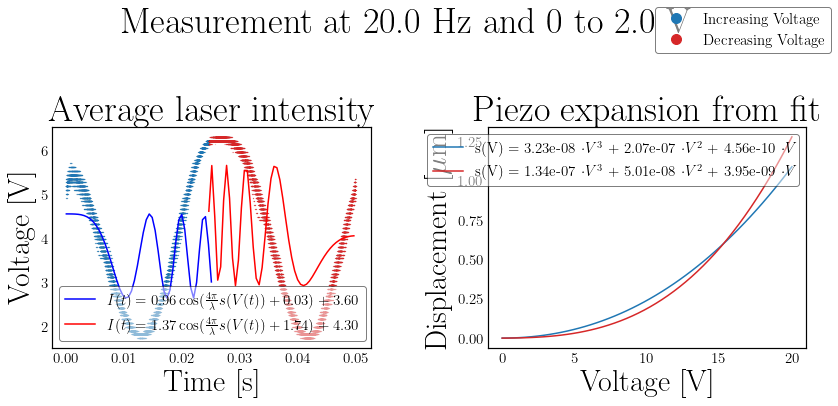

In [11]:
fig, axes = plt.subplots(1,2)

axes[0].plot(new_time_up, new_channel_a_up, "o", markersize = 0.1, color="C0", label ="Increasing Voltage")
axes[0].plot(new_time_down + new_time_up[-1], new_channel_a_down, "o", markersize = 0.1, color="C3", label = "Decreasing Voltage")
fig.legend(markerscale = 100)

t = np.linspace(0, T/2)
a,b1,b2,b3,c,d = fit_up[0]
label_up = f"$I(t) = {a:.2f}\\cos(\\frac{{4\\pi}}{{\\lambda}}s(V(t)) + {c:.2f}) + {d:.2f}$"
plot1, = axes[0].plot(t, fit_func_up(t,*fit_up[0]), color = "blue", label = label_up)
a,b1,b2,b3,c,d = fit_down[0]
label_down = f"$I(t) = {a:.2f}\\cos(\\frac{{4\\pi}}{{\\lambda}}s(V(t)) + {c:.2f}) + {d:.2f}$"
plot2, = axes[0].plot(t + new_time_up[-1], fit_func_down(t,*fit_down[0]), color = "red", label = label_down)
axes[0].legend(handles = (plot1,plot2), loc = "lower left")

ax.plot(times, tops, "+", color = "C3", label = "Peaks")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title(f"Average laser intensity")

a,b1,b2,b3,c,d = fit_up[0]
axes[1].plot(V_up(t) * 10, (b1 * V_up(t)**3 + b2 * V_up(t)**2 + b3 * V_up(t)) * 1e6, color = "C0", label = f"s(V) = {b1:.2e} $\\cdot V^3$ + {b2:.2e} $\\cdot V^2$ + {b3:.2e} $\\cdot V$")
a,b1,b2,b3,c,d = fit_down[0]
axes[1].plot(V_down(t) * 10,  (b1 * V_down(t)**3 + b2 * V_down(t)**2 + b3 * V_down(t)) * 1e6, color = "C3", label = f"s(V) = {b1:.2e} $\\cdot V^3$ + {b2:.2e} $\\cdot V^2$ + {b3:.2e} $\\cdot V$")
axes[1].set_xlabel("Voltage [V]")
axes[1].set_ylabel("Displacement [$\\mu$m]")
axes[1].set_title(f"Piezo expansion from fit")
axes[1].legend()

fig.suptitle(f"Measurement at {f} Hz and 0 to {Vmax} V")
fig.tight_layout()

#fig.savefig(f"../Figures/IntensityFitThirdDegree({f:.1f}Hz{Vmax:.1f}V).svg")


In [12]:
a0 = (channel_a.max() - channel_a.min()) / 2
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, 2.78e-8, 1e-7, 0, d0]
lower_bounds = [0,0,0,0,-10]
upper_bounds = [10,np.inf,np.inf,np.inf,10]

V_up = lambda t: (2 * Vmax / T * t)
fit_func_up = lambda t, a, b1,b2, c, d: a*np.cos(2*np.pi / lamb * 2 * (b1 * V_up(t)**2 + b2 * V_up(t)) + c) + d
fit_up = curve_fit(fit_func_up, new_time_up, new_channel_a_up, p0, maxfev = 10000, bounds = (lower_bounds, upper_bounds))
print(fit_up[0], np.sqrt(np.diag(fit_up[1])))

V_down = lambda t: (-2 * Vmax / T * t + Vmax)
fit_func_down = lambda t, a, b1,b2, c, d: a*np.cos(2*np.pi / lamb * 2 * (b1 * V_down(t)**2 + b2 * V_down(t)) + c) + d
fit_down = curve_fit(fit_func_down, new_time_down, new_channel_a_down, p0, maxfev = 10000, bounds = (lower_bounds, upper_bounds))
print(fit_down[0], np.sqrt(np.diag(fit_down[1])))

[2.11159368e+00 2.75356808e-08 9.97415556e-08 5.63417765e-01
 3.93436141e+00] [1.37717598e-03 1.31903808e-10 3.10620950e-10 2.92618215e-03
 1.82911198e-03]
[2.27197759e+00 3.11826413e-39 1.50738959e-07 1.23547415e+00
 4.13690410e+00] [1.23491381e-03 1.12155847e-10 2.36836982e-10 1.64466311e-03
 1.63533926e-03]


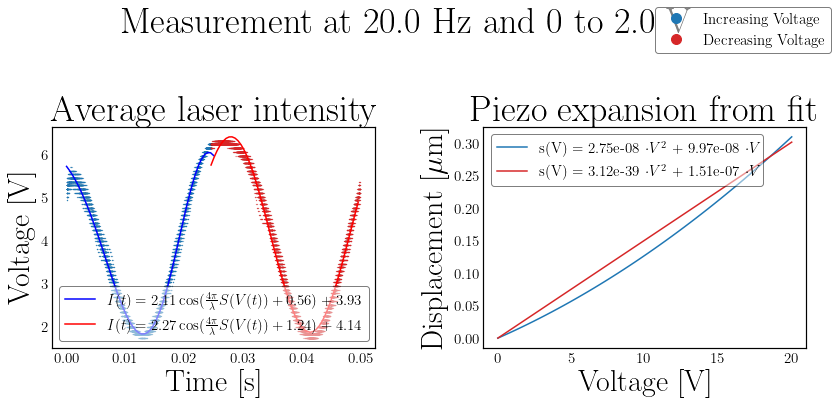

In [13]:
fig, axes = plt.subplots(1,2)

axes[0].plot(new_time_up, new_channel_a_up, "o", markersize = 0.1, color="C0", label ="Increasing Voltage")
axes[0].plot(new_time_down + new_time_up[-1], new_channel_a_down, "o", markersize = 0.1, color="C3", label = "Decreasing Voltage")
fig.legend(markerscale = 100)

t = np.linspace(0, T/2)
a,b1,b2,c,d = fit_up[0]
label_up = f"$I(t) = {a:.2f}\\cos(\\frac{{4\\pi}}{{\\lambda}}S(V(t)) + {c:.2f}) + {d:.2f}$"
plot1, = axes[0].plot(t, fit_func_up(t,*fit_up[0]), color = "blue", label = label_up)
a,b1,b2,c,d = fit_down[0]
label_down = f"$I(t) = {a:.2f}\\cos(\\frac{{4\\pi}}{{\\lambda}}S(V(t)) + {c:.2f}) + {d:.2f}$"
plot2, = axes[0].plot(t + new_time_up[-1], fit_func_down(t,*fit_down[0]), color = "red", label = label_down)
axes[0].legend(handles = (plot1,plot2), loc = "lower left")

ax.plot(times, tops, "+", color = "C3", label = "Peaks")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title(f"Average laser intensity")

a,b1,b2,c,d = fit_up[0]
axes[1].plot(V_up(t) * 10, (b1 * V_up(t)**2 + b2 * V_up(t)) * 1e6, color = "C0", label = f"s(V) = {b1:.2e} $\\cdot V^2$ + {b2:.2e} $\\cdot V$")
a,b1,b2,c,d = fit_down[0]
axes[1].plot(V_down(t) * 10,  (b1 * V_down(t)**2 + b2 * V_down(t)) * 1e6, color = "C3", label = f"s(V) = {b1:.2e} $\\cdot V^2$ + {b2:.2e} $\\cdot V$")
axes[1].set_xlabel("Voltage [V]")
axes[1].set_ylabel("Displacement [$\\mu$m]")
axes[1].set_title(f"Piezo expansion from fit")
axes[1].legend()

fig.suptitle(f"Measurement at {f} Hz and 0 to {Vmax} V")
fig.tight_layout()

fig.savefig(f"../Figures/IntensityFitSecondDegree({f:.1f}Hz{Vmax:.1f}V).svg")


In [14]:
# V_up = new_time_up * Vmax / new_time_up.max()
# I = new_channel_a_up

# deltaPhi = []

# for i, interval in enumerate(new_time_parts_up):
#     try:
#         index = len(np.concatenate(new_time_parts_up[:i]))
#     except: 
#         index = 0
#     intI = I[index:index + len(interval)]
#     deltaPhi += [np.arccos(2 * intI / intI.max() - 1)]

# phi_segments = []

# for intervalPhi in deltaPhi:
#     diffs = np.abs(np.diff(intervalPhi, prepend=intervalPhi[0]))
#     cumulative = np.cumsum(diffs)
#     phi_segments.append(cumulative)

# phi_list_up = phi_segments 
# phi_continuous = np.concatenate(phi_segments)
# s_up = (lamb / (4 * np.pi)) * phi_continuous

In [15]:
# V_down = Vmax - new_time_down * Vmax / new_time_down.max()
# I = new_channel_a_down

# deltaPhi = []

# for i, interval in enumerate(new_time_parts_down):
#     try:
#         index = len(np.concatenate(new_time_parts_down[:i]))
#     except: 
#         index = 0
#     intI = I[index:index + len(interval)]
#     deltaPhi += [np.arccos(2 * intI / intI.max() - 1)]

# phi_segments = []

# for intervalPhi in deltaPhi:
#     diffs = np.abs(np.diff(intervalPhi, prepend=intervalPhi[0]))
#     cumulative = np.cumsum(diffs)
#     phi_segments.append(cumulative)

# phi_list_down = phi_segments
# phi_continuous = np.concatenate(phi_list_down)
# s_down = lamb / (4 * np.pi) * phi_continuous

In [16]:
# up_fit = np.polyfit(V_up,s_up, 3)
# down_fit = np.polyfit(V_down,s_down, 3)
# f = lambda x,a,b,c,d: a*x**3 + b*x**2 + c*x + d

# V = np.linspace(0,Vmax,100)

# fig, ax = plt.subplots()
# #ax.plot(new_time_up * Vmax / new_time_up.max(), s_up, "o", markersize = 0.1, label = "up")
# #ax.plot(Vmax - new_time_down * Vmax / new_time_down.max(), s_down, "o", markersize = 0.1, label = "down")
# ax.plot((Vmax - V) * 10, (f(V[-1], *up_fit) - f(Vmax - V, *down_fit)) * 1e6, label = "Decreasing Voltage")
# ax.plot(V * 10, f(V, *up_fit) * 1e6, label = "Increasing Voltage")
# ax.legend(markerscale = 100)
# ax.set_xlabel("Voltage [V]")
# ax.set_ylabel("Displacement [$\\mu$m]")

In [17]:
# s_up = []
# s_down = []

# # Case: Starts with an Up ramp (tops[0] < 1 usually implies starting low)
# if tops[0] < 1:
#     for i in range(len(phi_list_up)):
#         # 1. The Up ramp
#         if i == 0:
#             # First ramp starts at 0
#             curr_up = np.array(phi_list_up[i])
#         else:
#             # Subsequent Up ramps start where the PREVIOUS Down ramp ended
#             curr_up = np.array(phi_list_up[i]) + s_down[i-1][-1]
#         s_up.append(curr_up)
        
#         # 2. The Down ramp (connects to the Up ramp that JUST finished)
#         # Note: Since phi_list_down is cumulative displacement, we subtract it from the peak
#         if i < len(phi_list_down):
#             curr_down = s_up[i][-1] - np.array(phi_list_down[i])
#             s_down.append(curr_down)

# # Case: Starts with a Down ramp
# else:
#     for i in range(len(phi_list_down)):
#         if i == 0:
#             curr_down = -np.array(phi_list_down[i]) # Starting from a relative 0 peak
#         else:
#             curr_down = s_up[i-1][-1] - np.array(phi_list_down[i])
#         s_down.append(curr_down)
        
#         if i < len(phi_list_up):
#             curr_up = s_down[i][-1] + np.array(phi_list_up[i])
#             s_up.append(curr_up)

# s_up_total = np.concatenate(s_up)
# s_down_total = np.concatenate(s_down)

# # Create a 'global index' for the whole dataset to find the trend
# x_total = np.arange(len(s_up_total)) 

# # Fit a line to the data (this finds the average drift slope)
# slope, intercept = np.polyfit(x_total, s_up_total, 1)

# # Subtract that slope from your results
# s_up_detrended = s_up_total - (slope * x_total)
# s_down_detrended = s_down_total - (slope * np.arange(len(s_down_total)))

In [18]:
# if tops[0] < 1:
#     s_down = [phi_list_up[i][-1] - np.array(phi_list_down[i])  for i in range(len(phi_list_down))]
#     s_up = [phi_list_up[0]] + [phi_list_down[i-1][-1] - np.array(phi_list_up[i]) for i in range(1,len(phi_list_up))]
# else: 
#     s_up = [phi_list_down[i][-1] + np.array(phi_list_up[i]) for i in range(len(phi_list_up))]
#     s_down = [-np.array(phi_list_down[0])] + [phi_list_up[i-1][-1] - np.array(phi_list_down[i])  for i in range(1,len(phi_list_down))]

# s_up = np.concatenate(s_up)
# s_down = np.concatenate(s_down)